<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
uploaded = files.upload()

Saving glass (2).xlsx to glass (2) (1).xlsx


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the glass dataset without header inference to inspect its raw structure
# glass_df = pd.read_excel('/content/glass (2).xlsx', header=None)

# To diagnose why the data is not being parsed into multiple columns, let's inspect sheet names
excel_file = pd.ExcelFile('/content/glass (2).xlsx')
print("Sheet names in the Excel file:")
print(excel_file.sheet_names)

# Display first 25 rows and info to identify actual data start and columns (commented out for now)
# print("Raw Dataset Info (first 25 rows, all columns, to identify actual data):")
# print(glass_df.info())
# print("\nFirst 25 rows of the raw dataset:")
# print(glass_df.head(25))

# Commenting out subsequent lines until the DataFrame is correctly loaded
# # Check for missing values
# print("\nMissing values:")
# print(glass_df.isnull().sum())

# # Basic statistics
# print("\nBasic statistics:")
# print(glass_df.describe())

# # Target variable distribution
# print("\nTarget variable distribution:")
# print(glass_df['Type'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

First 5 rows:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.5

<Figure size 1500x1000 with 0 Axes>

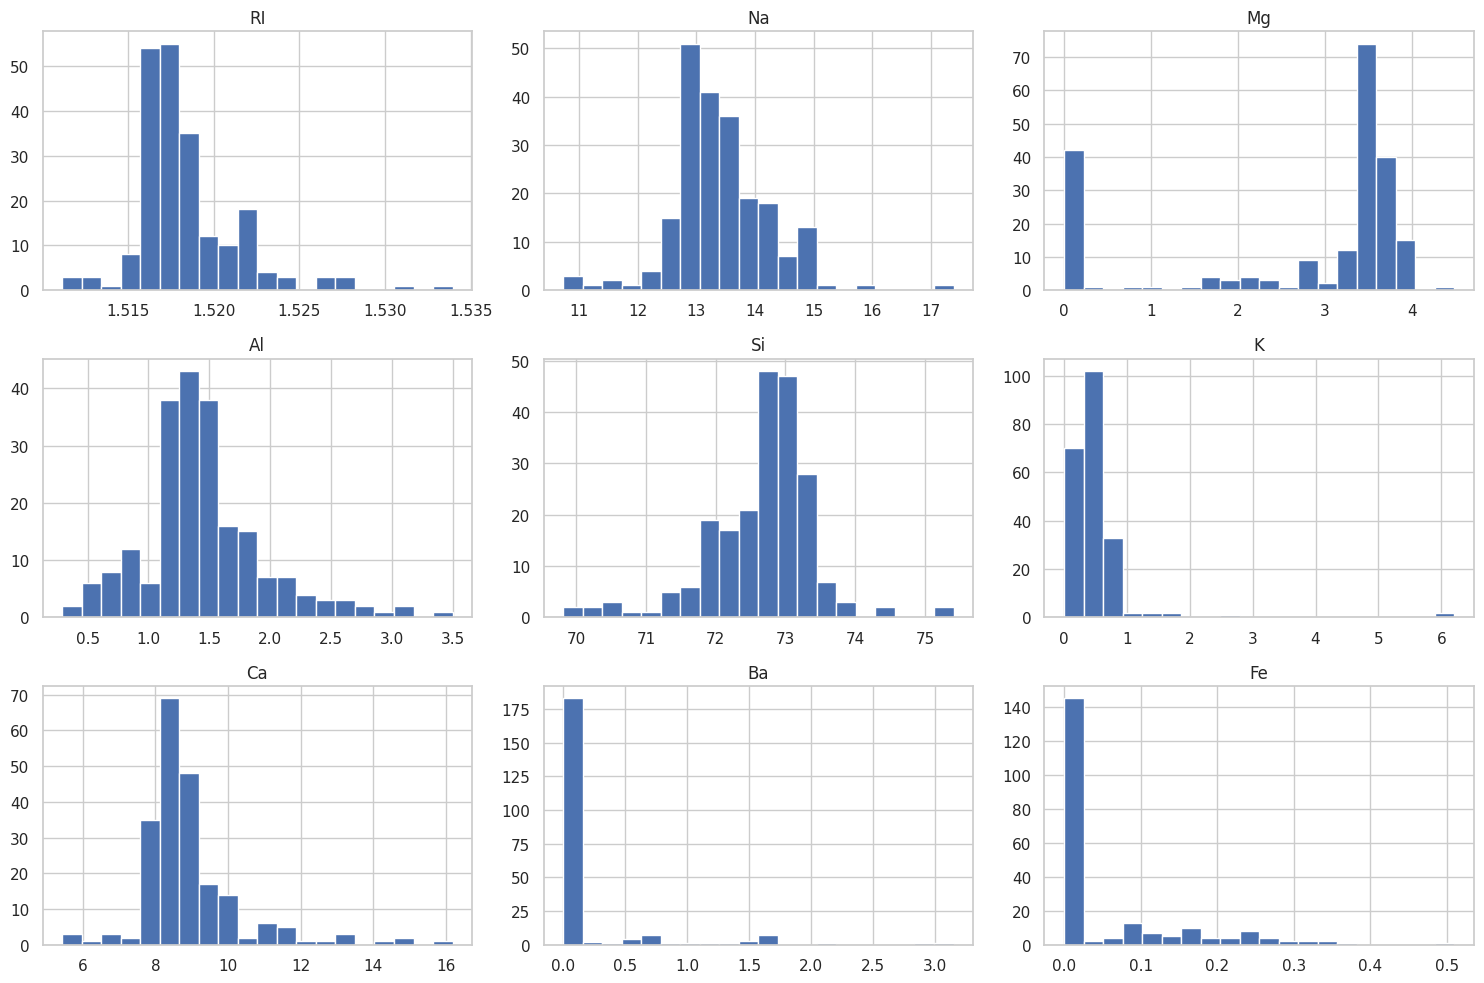

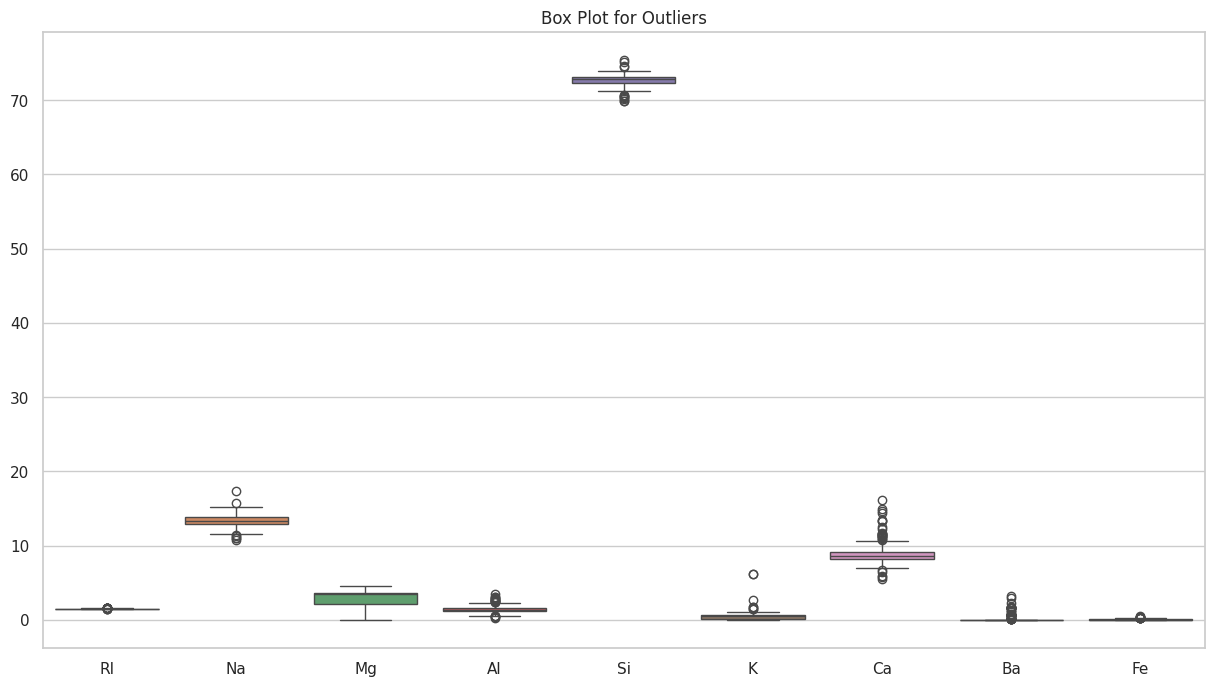

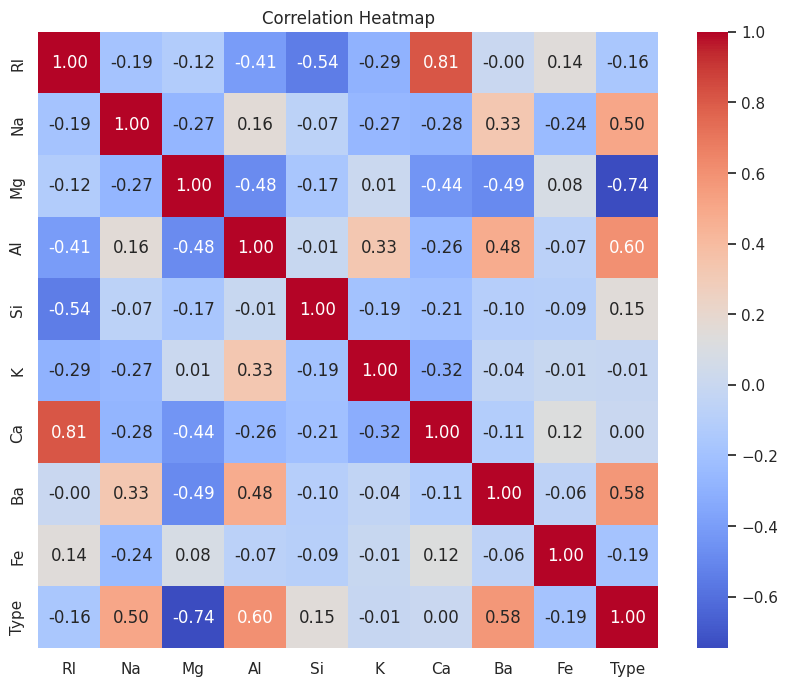

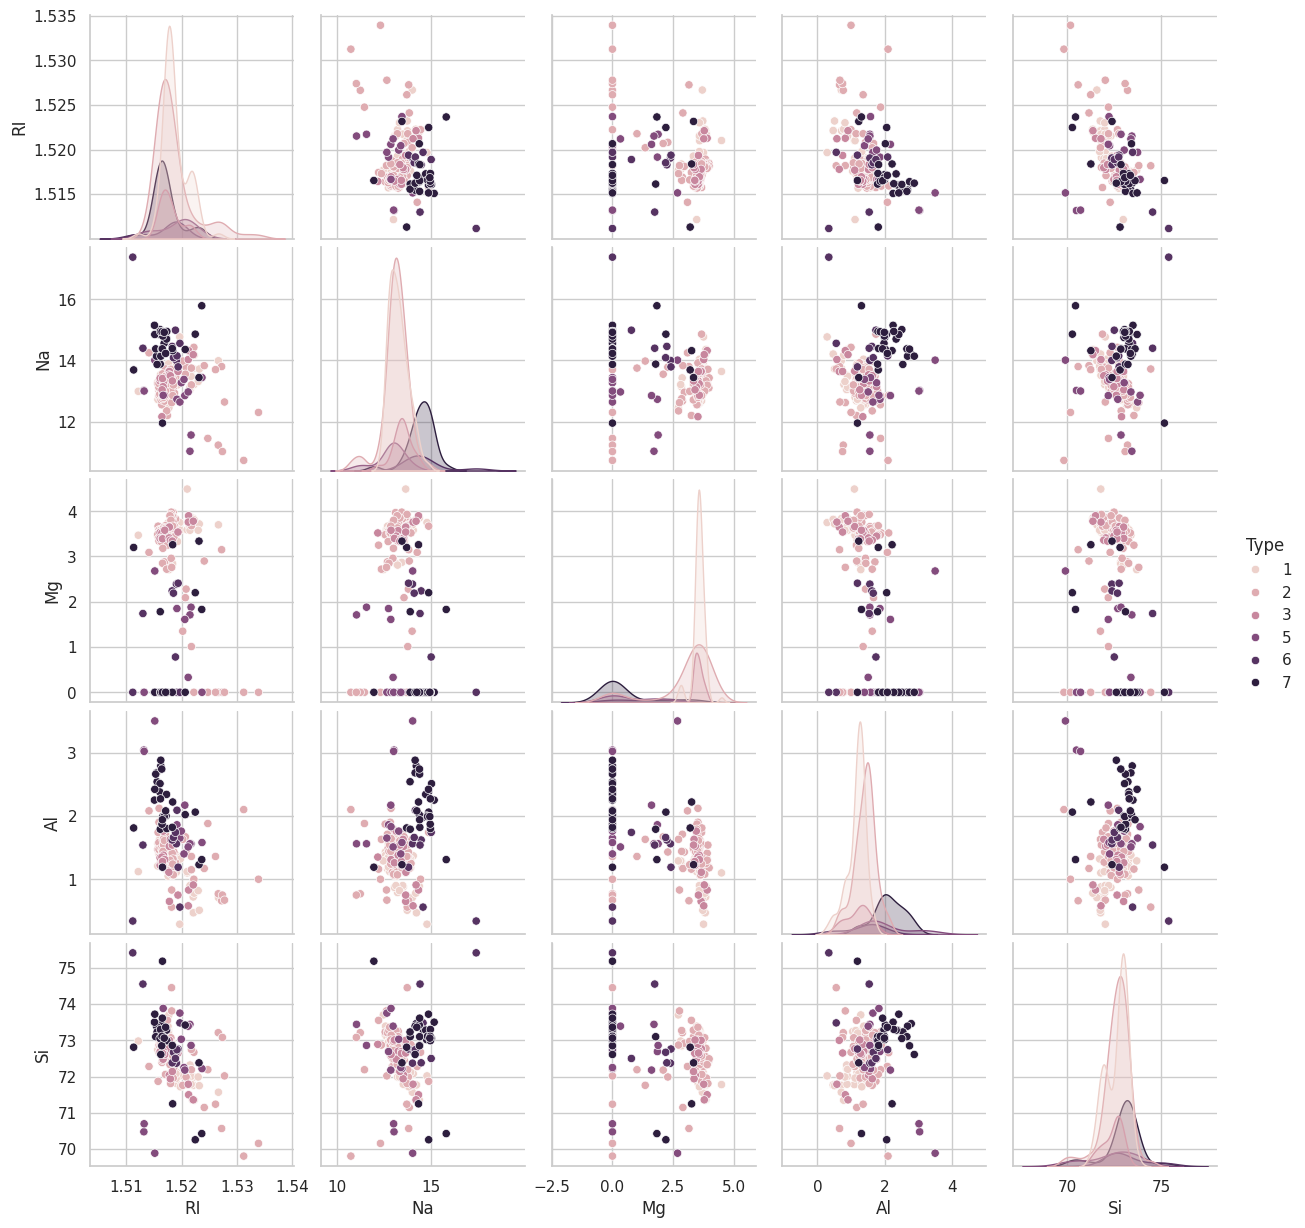

In [12]:
# Set plot style
sns.set(style="whitegrid")

# 1. Histograms for all features
plt.figure(figsize=(15, 10))
glass_df.iloc[:, :-1].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.savefig('histograms.png')

# 2. Box plots to check for outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=glass_df.iloc[:, :-1])
plt.title("Box Plot for Outliers")
plt.savefig('boxplots.png')

# 3. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(glass_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig('heatmap.png')

# 4. Pairplot (Sampling some columns if too many, but here we have 9, so let's try a few key ones or all)
# Only taking a few to keep it readable
sns.pairplot(glass_df, hue='Type', vars=['RI', 'Na', 'Mg', 'Al', 'Si'])
plt.savefig('pairplot.png')

In [13]:
# Check for duplicates
duplicates = glass_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    glass_df = glass_df.drop_duplicates()
    print("Duplicates removed.")

# Define features and target
X = glass_df.drop('Type', axis=1)
y = glass_df['Type']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Split data (stratified split to maintain class ratios)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle imbalance using SMOTE on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nResampled training set shape: {X_train_res.shape}")
print(f"Resampled target distribution:\n{y_train_res.value_counts()}")

# Initialize models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
bagging_model = BaggingClassifier(random_state=42)
boosting_model = GradientBoostingClassifier(random_state=42)

# Train and evaluate models
models = {
    "Random Forest": rf_model,
    "Bagging": bagging_model,
    "Boosting": boosting_model
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "Accuracy": acc,
        "F1-Score": f1,
        "Report": report
    }

    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

# Comparison Summary
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["Accuracy"] for m in results],
    "F1-Score": [results[m]["F1-Score"] for m in results]
})
print("\nModel Comparison:")
print(summary_df)

Number of duplicate rows: 1
Duplicates removed.

Resampled training set shape: (366, 9)
Resampled target distribution:
Type
7    61
1    61
2    61
3    61
5    61
6    61
Name: count, dtype: int64

--- Random Forest Results ---
Accuracy: 0.8140
F1-Score: 0.8161
              precision    recall  f1-score   support

           1       0.85      0.79      0.81        14
           2       0.79      0.73      0.76        15
           3       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.81        43
   macro avg       0.82      0.89      0.84        43
weighted avg       0.83      0.81      0.82        43


--- Bagging Results ---
Accuracy: 0.7907
F1-Score: 0.8008
              precision    recall  f1-score   support

           1       0.91      0.71      0.80        14
           2       0.79   

In [14]:
# Check for duplicates again
duplicates = glass_df.duplicated().sum()
if duplicates > 0:
    glass_df = glass_df.drop_duplicates()
    print(f"Number of duplicate rows removed: {duplicates}")

# Define features and target
X = glass_df.drop('Type', axis=1)
y = glass_df['Type']

# Split data (stratified split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Initialize models with class weighting where possible to handle imbalance
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
bagging_model = BaggingClassifier(n_estimators=100, random_state=42)
boosting_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Dictionary to store performance results
results = {}

for name, model in [("Random Forest", rf_model), ("Bagging", bagging_model), ("Boosting", boosting_model)]:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        "Accuracy": acc,
        "F1-Score": f1,
        "Report": classification_report(y_test, y_pred, output_dict=True)
    }

    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

# Compare the results
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["Accuracy"] for m in results],
    "F1-Score": [results[m]["F1-Score"] for m in results]
})
print("\nModel Comparison Summary:")
print(summary_df)


--- Random Forest Results ---
Accuracy: 0.8372
F1-Score: 0.8382
              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.80      0.80      0.80        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.84        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.85      0.84      0.84        43


--- Bagging Results ---
Accuracy: 0.7674
F1-Score: 0.7648
              precision    recall  f1-score   support

           1       0.77      0.71      0.74        14
           2       0.79      0.73      0.76        15
           3       0.67      0.67      0.67         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
        

1. Bagging and Boosting: Differences
Bagging (Bootstrap Aggregating):

How it works: It builds multiple independent models (typically deep Decision Trees) in parallel using different random subsets of the data (with replacement). The final prediction is an average (regression) or majority vote (classification).

Goal: Reduces variance and prevents overfitting.

Example: Random Forest (a specific type of Bagging where features are also randomly selected).

Boosting:

How it works: It builds models sequentially. Each new model attempts to correct the errors made by the previous models by focusing more on the misclassified observations.

Goal: Reduces bias and variance, aiming for a strong learner.

Example: Gradient Boosting, AdaBoost, XGBoost.

2. Handling Imbalance in Data
Imbalanced data occurs when some classes have significantly fewer samples than others. This can lead to a model that is biased toward the majority class. Ways to handle this include:

Resampling:

Oversampling: Increasing the minority class (e.g., SMOTE - Synthetic Minority Over-sampling Technique).

Undersampling: Reducing the majority class samples.

Algorithmic Adjustment: Using parameters like class_weight='balanced' which assigns higher penalties to misclassifying the minority class.

Metrics Selection: Focusing on F1-Score, Precision-Recall curves, or AUC-ROC rather than just Accuracy, which can be misleading in imbalanced datasets.